In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

In [4]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x

In [7]:
model = SimpleCNN().to(device)

In [8]:
criterion = nn.CrossEntropyLoss()

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
epochs = 5
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {running_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")

Epoch [1/5]
Train Loss: 20.7769
Train Accuracy: 99.30%
Epoch [2/5]
Train Loss: 19.1285
Train Accuracy: 99.34%
Epoch [3/5]
Train Loss: 17.8131
Train Accuracy: 99.36%
Epoch [4/5]
Train Loss: 18.2192
Train Accuracy: 99.37%
Epoch [5/5]
Train Loss: 14.9374
Train Accuracy: 99.47%


In [33]:
model.eval()
correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
val_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total
val_losses.append(val_loss)
adam_accuracy = test_accuracy
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy1: {test_accuracy:.2f}%")


Test Loss: 3.5884
Test Accuracy1: 99.26%


In [38]:
model = SimpleCNN().to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [39]:
train_accuracies = []
val_accuracies = []
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    train_accuracies.append(train_accuracy)
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {running_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")

Epoch [1/5]
Train Loss: 323.6540
Train Accuracy: 88.96%
Epoch [2/5]
Train Loss: 89.4618
Train Accuracy: 97.09%
Epoch [3/5]
Train Loss: 66.2363
Train Accuracy: 97.88%
Epoch [4/5]
Train Loss: 53.4350
Train Accuracy: 98.31%
Epoch [5/5]
Train Loss: 45.4546
Train Accuracy: 98.58%


In [52]:
model.eval()
correct = 0
total = 0
test_loss = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        val_loss = test_loss / len(test_loader)
val_accuracy = 100 * correct / total
val_losses.append(val_loss)
val_accuracies.append(val_accuracy)
sgd_accuracy = val_accuracy
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {sgd_accuracy:.2f}%")


Test Loss: 4.3680
Test Accuracy: 99.10%


In [53]:
print(f"Adam Accuracy: {adam_accuracy:.2f}%")
print(f"SGD Accuracy: {sgd_accuracy:.2f}%")

Adam Accuracy: 99.26%
SGD Accuracy: 99.10%


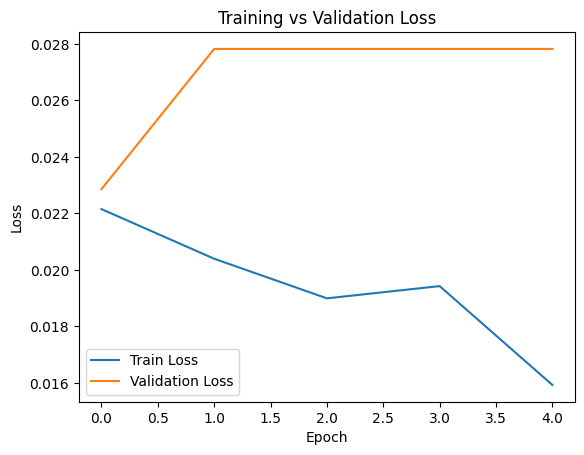

In [54]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

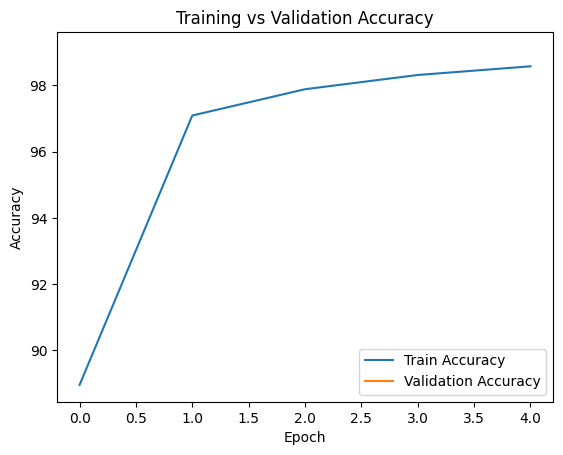

In [55]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()